# Volumetric benchmarking

A volumetric benchmark maps a (*width*, *depth*) pair to a suite of test circuits of approximately that shape, and reports one success measure between 0 and 1 for the suite (1 being better performance). Collect those measures over many shapes and you learn something a single number cannot tell you: the tradeoff between how wide and how deep a processor can run circuits before the signal dies. For the theory and motivation, see [Blume-Kohout and Young](https://arxiv.org/abs/1904.05546).

Nothing in the definition says which circuits go in the suite. This page works through two choices on the same simulated 4-qubit ring. The first uses direct RB circuits, and follows the whole pyGSTi workflow from experiment design to a heatmap over shapes. The second uses mirror circuits, both randomized and periodic, and reproduces the style of analysis in ["Measuring the Capabilities of Quantum Computers"](https://arxiv.org/abs/2008.11294): capability regions, stacked volumetric plots, and RB error rates pulled out of the same data.

In [1]:
import numpy as np
import pygsti
import pygsti.protocols as pp
from pygsti.processors import QubitProcessorSpec as QPS
from pygsti.processors import CliffordCompilationRules as CCR

## The processor under test

Both benchmarks target the same device: a ring of 4 qubits, each with the four single-qubit gates $X(\pm\pi/2)$ and $Y(\pm\pi/2)$, and CPHASE available between neighbors. A `QubitProcessorSpec` holds that description (see the [tutorial on processor specs](../workflow/DescribeYourDevice)).

The RB-style circuit samplers below need to know how to build Cliffords out of these native gates, which is what the `CliffordCompilationRules` objects are for. The `'absolute'` rules compile exact Cliffords; the `'paulieq'` rules compile them up to Paulis, which is all direct RB needs for its layers.

In [2]:
n_qubits = 4
qubit_labels = ['Q0', 'Q1', 'Q2', 'Q3']
gate_names = ['Gxpi2', 'Gxmpi2', 'Gypi2', 'Gympi2', 'Gcphase']
availability = {'Gcphase': [('Q0', 'Q1'), ('Q1', 'Q2'), ('Q2', 'Q3'), ('Q3', 'Q0')]}

pspec = QPS(n_qubits, gate_names, availability=availability, qubit_labels=qubit_labels)

compilations = {'absolute': CCR.create_standard(pspec, 'absolute', ('paulis', '1Qcliffords'), verbosity=0),
                'paulieq': CCR.create_standard(pspec, 'paulieq', ('1Qcliffords', 'allcnots'), verbosity=0)}

## A direct-RB volumetric benchmark

Direct RB gives you a family of test suites indexed by depth. Run those suites on different subsets of the ring and you get the width axis too.

### Build the experiment design

Create one `DirectRBDesign` per qubit subset, passing a different `qubit_labels` each time. Attach a `ByDepthSummaryStatistics` protocol to each design as a *default protocol*, so that running everything later is a single call.

Some of these suites can share a run. Wrapping several designs in a `SimultaneousExperimentDesign` says "execute these side by side on disjoint qubits", which saves time at the cost of whatever crosstalk error that introduces. Below there are two simultaneous designs, one running two 2-qubit suites at once and one running four 1-qubit suites at once, joined by a `CombinedExperimentDesign`. If you didn't want anything run simultaneously, you could put all six designs directly under the `CombinedExperimentDesign`.

The result is a single object, `entire_design`, holding every circuit the experiment needs. Write it to disk and go collect data.

In [3]:
depths = [0, 2, 4, 8]
circuits_per_depth = 3

VB_design01 = pp.DirectRBDesign(pspec, compilations, depths, circuits_per_depth, qubit_labels=['Q0', 'Q1'])
VB_design23 = pp.DirectRBDesign(pspec, compilations, depths, circuits_per_depth, qubit_labels=['Q2', 'Q3'])
VB_design01.add_default_protocol(pp.ByDepthSummaryStatistics(statistics_to_compute=('polarization',)))
VB_design23.add_default_protocol(pp.ByDepthSummaryStatistics(statistics_to_compute=('polarization',)))

designS1 = pp.SimultaneousExperimentDesign([VB_design01, VB_design23], qubit_labels=qubit_labels)

one_qubit_designs = []
for q in qubit_labels:
    d = pp.DirectRBDesign(pspec, compilations, depths, circuits_per_depth, qubit_labels=[q])
    d.add_default_protocol(pp.ByDepthSummaryStatistics(statistics_to_compute=('polarization',)))
    one_qubit_designs.append(d)

designS2 = pp.SimultaneousExperimentDesign(one_qubit_designs, qubit_labels=qubit_labels)

entire_design = pp.CombinedExperimentDesign({"specA": designS1, "specB": designS2})
try:
    import shutil; shutil.rmtree('../../../tutorial_files/vb_example')  # stale files can be problematic
except FileNotFoundError:
    pass
pygsti.io.write_empty_protocol_data("../../../tutorial_files/vb_example", entire_design)

- Sampling 3 circuits at DRB length 0 (1 of 4 depths) with seed 81094
- Sampling 3 circuits at DRB length 2 (2 of 4 depths) with seed 81097
- Sampling 3 circuits at DRB length 4 (3 of 4 depths) with seed 81100
- Sampling 3 circuits at DRB length 8 (4 of 4 depths) with seed 81103
- Sampling 3 circuits at DRB length 0 (1 of 4 depths) with seed 962162
- Sampling 3 circuits at DRB length 2 (2 of 4 depths) with seed 962165
- Sampling 3 circuits at DRB length 4 (3 of 4 depths) with seed 962168
- Sampling 3 circuits at DRB length 8 (4 of 4 depths) with seed 962171
- Sampling 3 circuits at DRB length 0 (1 of 4 depths) with seed 183434
- Sampling 3 circuits at DRB length 2 (2 of 4 depths) with seed 183437
- Sampling 3 circuits at DRB length 4 (3 of 4 depths) with seed 183440
- Sampling 3 circuits at DRB length 8 (4 of 4 depths) with seed 183443
- Sampling 3 circuits at DRB length 0 (1 of 4 depths) with seed 616357
- Sampling 3 circuits at DRB length 2 (2 of 4 depths) with seed 616360
- Sampling

### Collect the data

On real hardware you'd now run the circuits listed in the design and fill in the empty template dataset that `write_empty_protocol_data` left on disk. There's no processor here, so simulate the data instead with a depolarizing model.

In [4]:
mdl_datagen = pygsti.models.create_crosstalk_free_model(pspec, ideal_gate_type='full TP')
for gate in mdl_datagen.operation_blks['gates'].values():
    gate.depolarize(0.01)
pygsti.io.fill_in_empty_dataset_with_fake_data("../../../tutorial_files/vb_example/data/dataset.txt", mdl_datagen,
                                               num_samples=1000, seed=2020)

<pygsti.data.dataset.DataSet at 0xADDRESS>

Read the filled-in template back from the same root directory. This picks up both `dataset.txt` and the experiment design stored under `.../vb_example/edesign`.

In [5]:
data = pygsti.io.read_data_from_dir('../../../tutorial_files/vb_example')

### Run the protocols

`ByDepthSummaryStatistics` computes per-depth summary statistics from definite-outcome circuit data. Because an instance was attached to each sub-design as a default protocol, `run_default_protocols` can walk the tree of designs, run each protocol where it belongs, and keep track of where each result sits in the hierarchy. The instances above were told to compute only `'polarization'`, which is the metric plotted next.

In [6]:
results = pp.run_default_protocols(data)

Running protocol ByDepthSummaryStatistics at ./specA/('Q0', 'Q1')
Running protocol ByDepthSummaryStatistics at ./specA/('Q2', 'Q3')
Running protocol ByDepthSummaryStatistics at ./specB/('Q0',)
Running protocol ByDepthSummaryStatistics at ./specB/('Q1',)
Running protocol ByDepthSummaryStatistics at ./specB/('Q2',)
Running protocol ByDepthSummaryStatistics at ./specB/('Q3',)


### Plot the shapes

pyGSTi has no built-in plot for a collection of direct-RB volumetric data, so convert the results object to a [pandas](https://pandas.pydata.org) data frame and slice it yourself. Below the plotting is done with [Plotly](https://plot.ly/python); any library will do.

In [7]:
df = results.to_dataframe()  # you'll need the 'pandas' python package for this
df.head()  # the raw data

,Path,ProtocolName,ProtocolType,Qubits,ValueName,Depth,Width,CircuitIndex,Value
0,"(specA, (Q0, Q1))",ByDepthSummaryStatistics,ByDepthSummaryStatistics,"(Q0, Q1)",polarization,0,2,0,0.840000
1,"(specA, (Q0, Q1))",ByDepthSummaryStatistics,ByDepthSummaryStatistics,"(Q0, Q1)",polarization,0,2,1,0.756000
2,"(specA, (Q0, Q1))",ByDepthSummaryStatistics,ByDepthSummaryStatistics,"(Q0, Q1)",polarization,0,2,2,0.925333
3,"(specA, (Q0, Q1))",ByDepthSummaryStatistics,ByDepthSummaryStatistics,"(Q0, Q1)",polarization,2,2,0,0.892000
4,"(specA, (Q0, Q1))",ByDepthSummaryStatistics,ByDepthSummaryStatistics,"(Q0, Q1)",polarization,2,2,1,0.729333


In [8]:
df_relevant_cols = df.loc[:, ['Value', 'ValueName', 'Depth', 'Width']]
df_vb = df_relevant_cols[df_relevant_cols['ValueName'] == 'polarization'].loc[:, ['Value', 'Depth', 'Width']]
df_vb.head()

,Value,Depth,Width
0,0.840000,0,2
1,0.756000,0,2
2,0.925333,0,2
3,0.892000,2,2
4,0.729333,2,2


In [9]:
vb_widths = sorted(df_vb.Width.unique())
vb_depths = sorted(df_vb.Depth.unique())
vals = [[df_vb[(df_vb['Depth'] == d) & (df_vb['Width'] == w)]['Value'].mean()
         for d in vb_depths] for w in vb_widths]

In [10]:
import plotly.graph_objects as go  # you'll need the 'plotly' python package for this

fig = go.Figure(data=go.Heatmap(z=vals, x=vb_depths, y=vb_widths, colorscale='Bluered_r'))
fig.update_layout(title='Volumetric benchmarking example',
                  xaxis={'title': 'Depth'}, yaxis={'title': 'Width'},
                  height=300, width=400)
fig.show()

## Mirror-circuit benchmarks

Mirror circuits let you push the same idea much further in depth, because they have an efficiently predictable target outcome no matter how deep they get. The rest of this page builds an experiment in the shape of the ones in arXiv:2008.11294 and produces the plots that paper uses.

Two circuit families go into it. *Randomized* mirror circuits (`MirrorRBDesign`) sample a disordered layer sequence and then mirror it. *Periodic* mirror circuits (`PeriodicMirrorCircuitDesign`) repeat a randomly chosen germ instead, using the germ selection algorithm of arXiv:2008.11294, so coherent errors get a chance to accumulate over repetitions rather than averaging out. Sampling them side by side, at matched shapes, is what makes the comparison plots below meaningful.

In [11]:
from pygsti.protocols import MirrorRBDesign as RMCDesign
from pygsti.protocols import PeriodicMirrorCircuitDesign as PMCDesign
from pygsti.protocols import ByDepthSummaryStatistics as SummaryStats

clifford_compilations = {'absolute': compilations['absolute']}

Nothing here is tied to the $X(\pm\pi/2)$/$Y(\pm\pi/2)$/CPHASE gate set. A device whose native gates are the 24 single-qubit Cliffords plus CNOT works the same way, and its compilation rules need no arguments beyond the processor spec, because `create_standard` defaults to `'absolute'` rules for the single-qubit Cliffords:

In [12]:
clifford_gate_names = ['Gcnot'] + ['Gc{}'.format(i) for i in range(24)]
clifford_availability = {'Gcnot': [(qubit_labels[i], qubit_labels[(i + 1) % n_qubits]) for i in range(n_qubits)]}
clifford_pspec = QPS(n_qubits, clifford_gate_names, availability=clifford_availability, qubit_labels=qubit_labels)

demo_design = RMCDesign(clifford_pspec, [0, 2, 4], 3,
                        clifford_compilations={'absolute': CCR.create_standard(clifford_pspec, verbosity=0)},
                        qubit_labels=tuple(qubit_labels), sampler='edgegrab', samplerargs=[2 / 8,])
print(len(demo_design.all_circuits_needing_data), 'circuits')

- Sampling 3 circuits at MRB length 0 (1 of 3 depths) with seed 181461
- Sampling 3 circuits at MRB length 2 (2 of 3 depths) with seed 181464
- Sampling 3 circuits at MRB length 4 (3 of 3 depths) with seed 181467
9 circuits


The rest of the page stays on `pspec`, so that the mirror-circuit results and the direct-RB results above describe one processor.

### Pick the circuit shapes

Wide circuits fail sooner than narrow ones, so running every depth at every width mostly buys you noise floor. The helper below trims each width's depth list at the point where the expected polarization drops under 1%, keeping one depth past the cutoff so you can see the signal hit the floor. Guessing the per-qubit error rate too low costs you run time and nothing else. You may prefer to choose the depths by hand.

In [13]:
# A guess at the rough per-qubit error rate, used only to pick a maximum depth per width.
estimated_qubit_error_rate = 0.005

def trim_depths(depths, w):
    target_polarization = 0.01
    maxdepth = np.log(target_polarization) / (w * np.log(1 - estimated_qubit_error_rate))
    trimmed_depths = [d for d in depths if d < maxdepth]
    numdepths = len(trimmed_depths)
    if numdepths < len(depths) and trimmed_depths[-1] < maxdepth:
        trimmed_depths.append(depths[numdepths])
    return trimmed_depths

Now set the sampling parameters. These follow the structure of Figs. 2 and 3 of arXiv:2008.11294, scaled down so the page runs in seconds: that paper used 40 circuits per shape and base depths out to $2^{14}$.

The qubit subsets here are just the first $w$ qubits of the ring. On real hardware you'd choose more carefully. In arXiv:2008.11294 the subsets were the qubits that looked best according to RB calibration data, though there's nothing privileged about that rule.

In [14]:
# Number of circuits per circuit shape (width and depth). Use 40 to replicate arXiv:2008.11294.
circuits_per_shape = 10

widths = [i for i in range(1, n_qubits + 1)]

base_depths = [0,] + [int(d) for d in 2**np.arange(1, 12)]
mirror_depths = {w: trim_depths(base_depths, w) for w in widths}

qubit_lists = {w: [tuple(qubit_labels[:w])] for w in widths}

for w in widths:
    print(w, mirror_depths[w], qubit_lists[w])

# Two-qubit gate density: the fraction of circuit locations occupied by a two-qubit gate,
# with each two-qubit gate occupying two locations.
xi = 1 / 8

1 [0, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] [('Q0',)]
2 [0, 2, 4, 8, 16, 32, 64, 128, 256, 512] [('Q0', 'Q1')]
3 [0, 2, 4, 8, 16, 32, 64, 128, 256, 512] [('Q0', 'Q1', 'Q2')]
4 [0, 2, 4, 8, 16, 32, 64, 128, 256] [('Q0', 'Q1', 'Q2', 'Q3')]


### Sample the circuits

`MirrorRBDesign` samples its layers with the `edgegrab` sampler, which is what arXiv:2008.11294 used for its Figs. 2 and 3 (Fig. 1d used a different sampler). Its `samplerargs[0]` is the two-qubit gate density in a sampled layer.

`PeriodicMirrorCircuitDesign` takes a `sampler` argument and stores it on the design, but does not sample with it. It builds germs with `create_random_germpower_mirror_circuits`, which has no sampler parameter at all and reads only `samplerargs[0]`, as the two-qubit gate density inside the germ. Passing `'edgegrab'` below is inert; it is there so the two calls read alike.

The two designs get different densities, `2 * xi` for the randomized circuits and `xi` for the periodic ones. Those numbers are not two settings of one knob: one governs a freshly sampled layer, the other a germ that then gets repeated, and the compiled circuits do not come out at equal measured two-qubit gate density either. Treat the pairing as a starting point to check against your own circuits, not as a matched control.

In [15]:
edesigns = {}
for w in widths:
    for qs in qubit_lists[w]:
        key = str(w) + '-' + '-'.join(qs) + '-' + 'RMCs'
        edesigns[key] = RMCDesign(pspec, mirror_depths[w], circuits_per_shape,
                                  clifford_compilations=clifford_compilations,
                                  qubit_labels=qs, sampler='edgegrab',
                                  samplerargs=[2 * xi,])

- Sampling 10 circuits at MRB length 0 (1 of 11 depths) with seed 332487
- Sampling 10 circuits at MRB length 2 (2 of 11 depths) with seed 332497
- Sampling 10 circuits at MRB length 4 (3 of 11 depths) with seed 332507
- Sampling 10 circuits at MRB length 8 (4 of 11 depths) with seed 332517
- Sampling 10 circuits at MRB length 16 (5 of 11 depths) with seed 332527
- Sampling 10 circuits at MRB length 32 (6 of 11 depths) with seed 332537
- Sampling 10 circuits at MRB length 64 (7 of 11 depths) with seed 332547
- Sampling 10 circuits at MRB length 128 (8 of 11 depths) with seed 332557
- Sampling 10 circuits at MRB length 256 (9 of 11 depths) with seed 332567
- Sampling 10 circuits at MRB length 512 (10 of 11 depths) with seed 332577
- Sampling 10 circuits at MRB length 1024 (11 of 11 depths) with seed 332587
- Sampling 10 circuits at MRB length 0 (1 of 10 depths) with seed 368330
- Sampling 10 circuits at MRB length 2 (2 of 10 depths) with seed 368340
- Sampling 10 circuits at MRB length 

In [16]:
for w in widths:
    for qs in qubit_lists[w]:
        key = str(w) + '-' + '-'.join(qs) + '-' + 'PMCs'
        edesigns[key] = PMCDesign(pspec, mirror_depths[w], circuits_per_shape,
                                  clifford_compilations=clifford_compilations,
                                  qubit_labels=qs, sampler='edgegrab',
                                  samplerargs=[xi,])

### Write out the circuits

Combine the designs, write the empty data template, and dump a shuffled circuit list. Run the circuits in random order: it keeps slow drift from correlating with circuit shape. pyGSTi can also hand you the circuits as OpenQASM if that's what your stack wants.

In [17]:
edesign = pygsti.protocols.CombinedExperimentDesign(edesigns)

pygsti.io.write_empty_protocol_data('../../../tutorial_files/test_mirror_benchmark', edesign, clobber_ok=True)

circuits = edesign.all_circuits_needing_data
np.random.shuffle(circuits)

# The non-shuffled list lives in the edesign folder; this is the order to actually run.
pygsti.io.write_circuit_list('../../../tutorial_files/test_mirror_benchmark/randomized_circuits.txt', circuits)

qasm = [c.convert_to_openqasm(standard_gates_version='x-sx-rz') for c in circuits]
print(len(circuits), 'circuits')

800 circuits


You'd run `circuits` (or `qasm`) on your device and drop the results into `test_mirror_benchmark/data/dataset.txt`, replacing the empty template. Here, simulate instead. The noise model gives every gate a coherent $Z$ over-rotation and a little stochastic $X$, with the two-qubit gate five times worse than the one-qubit gates on both coefficients.

In [18]:
lindblad_error_coeffs = {g: {('H', 'Z'): 0.01, ('S', 'X'): 0.001} for g in gate_names if g != 'Gcphase'}
lindblad_error_coeffs['Gcphase'] = {('H', 'ZZ'): 0.05, ('S', 'XI'): 0.005}
noisemodel = pygsti.models.create_crosstalk_free_model(pspec, lindblad_error_coeffs=lindblad_error_coeffs)
ds = pygsti.io.fill_in_empty_dataset_with_fake_data('../../../tutorial_files/test_mirror_benchmark/data/dataset.txt',
                                                    noisemodel, num_samples=1000, seed=1234)

In [19]:
mirror_data = pygsti.io.read_data_from_dir('../../../tutorial_files/test_mirror_benchmark')

### Summarize into a VB data frame

Run `ByDepthSummaryStatistics` over the whole design with a `SimpleRunner`, this time asking for several statistics, then convert to a data frame and wrap it in a `VBDataFrame`. That wrapper is what the plotting functions in `pygsti.report` consume.

Two fixups happen here. The `CircuitType` column is derived from the design keys, so it breaks if you rename them away from `RMCs`/`PMCs`. And `Depth` is doubled, because the mirror circuit generation code counts depth differently from arXiv:2008.11294.

In [20]:
statistics = ['polarization', 'success_probabilities', 'success_counts', 'total_counts', 'two_q_gate_count']
stats_generator = pygsti.protocols.SimpleRunner(SummaryStats(statistics_to_compute=statistics))

summary_data = stats_generator.run(mirror_data)

df = summary_data.to_dataframe('ValueName', drop_columns=['ProtocolName', 'ProtocolType'])

df['CircuitType'] = ['RMC' if 'RMCs' in p[0] else 'PMC' for p in df['Path']]
df['Depth'] = 2 * df['Depth']

vbdf = pygsti.protocols.VBDataFrame(df)

### Capability regions

A capability region plot divides the shape grid into shapes the processor succeeds at, shapes it fails at, and the indeterminate band between, using a hypothesis test at each shape. This is the plot from Fig. 3 of arXiv:2008.11294.

<repo>/pygsti/protocols/vbdataframe.py:118: RuntimeWarning: divide by zero encountered in log
  llr += -2 * (total_counts - s) * (_np.log(1 - threshold) - _np.log(1 - p))
<repo>/pygsti/protocols/vbdataframe.py:118: RuntimeWarning: invalid value encountered in scalar multiply
  llr += -2 * (total_counts - s) * (_np.log(1 - threshold) - _np.log(1 - p))
<repo>/pygsti/report/vbplot.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter([indd], [indw], marker="s", s=280 * scale - 30 * linewidth, c=point_color,


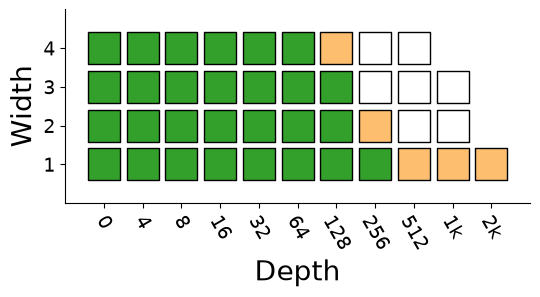

In [21]:
fig, ax = pygsti.report.capability_region_plot(vbdf, figsize=(6, 8), scale=2)

### Randomized versus periodic circuits

To compare the two circuit families directly, pull out the volumetric data for each. The `'monotonic_min'` statistic enforces the physically sensible reading that a processor which fails at some shape also fails at every larger one, and `no_data_action='min'` fills untested shapes with the floor value rather than leaving holes.

In [22]:
vb_min = {}
for circuit_type in ('RMC', 'PMC'):
    vbdf1 = vbdf.select_column_value('CircuitType', circuit_type)
    vb_min[circuit_type] = vbdf1.vb_data(metric='polarization', statistic='monotonic_min', no_data_action='min')

Drawing both on one axis, with the randomized data as small inner squares over the periodic data as large outer squares, gives the Fig. 2a comparison. Shapes where the inner and outer squares disagree in color are shapes where the two circuit families see different amounts of error.

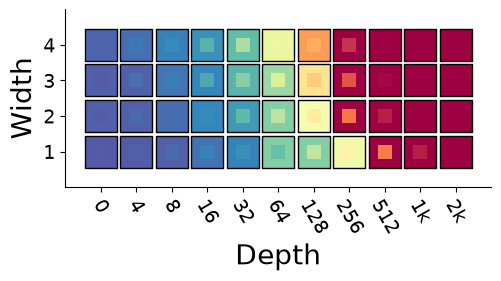

In [23]:
# From matplotlib>=3.9.0 the top-level cm registration functions are gone:
# https://matplotlib.org/stable/api/prev_api_changes/api_changes_3.9.0.html
try:
    from matplotlib import cm as _cm
    spectral = _cm.get_cmap('Spectral')
except AttributeError:
    import matplotlib as mpl
    spectral = mpl.colormaps['Spectral']

fig, ax = pygsti.report.volumetric_plot(vb_min['PMC'], scale=1.9, cmap=spectral, figsize=(5.5, 8))
fig, ax = pygsti.report.volumetric_plot(vb_min['RMC'], scale=0.4, cmap=spectral, fig=fig, ax=ax, linescale=0.)

The distribution plot draws the maximum, mean and minimum polarization at each shape as three concentric squares, so you see the spread across circuits rather than one pooled number. It also marks a success boundary for each of the three. Under the default `hypothesis_test='standard'` only the max and min boundaries are adjusted for statistical significance, so they separate from each other only where the data supports it; the mean boundary is drawn straight from the mean polarization. Pass `hypothesis_test='none'` to leave all three unadjusted. This is the plot from Fig. 1d of that paper, though the circuits here are sampled differently than the ones behind Fig. 1d, so don't expect the figures to match. Pass `cmap=None` for the paper's color map.

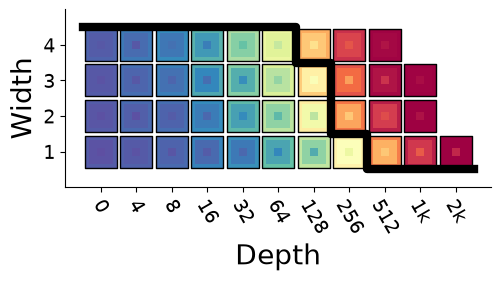

In [24]:
vbdf1 = vbdf.select_column_value('CircuitType', 'RMC')
fig, ax = pygsti.report.volumetric_distribution_plot(vbdf1, figsize=(5.5, 8), cmap=spectral)

### Error rates from the same data

Randomized mirror circuit data supports the usual RB analysis as well: fit the decay against depth and read off an average gate error rate. Use `datatype='adjusted_success_probabilities'`, which is the standard mirror RB choice, and `defaultfit='A-fixed'` to hold the asymptote at its theoretical value instead of fitting it.

In [25]:
rb = pygsti.protocols.RB(datatype='adjusted_success_probabilities', defaultfit='A-fixed')

rb_results = {}
r = {}
for key, subdata in mirror_data.items():
    if 'RMCs' in key:
        rb_results[key] = rb.run(subdata)
        w = int(key.split('-')[0])
        r[w] = rb_results[key].fits['A-fixed'].estimates['r']

Plotting the fitted error rate against width shows how error accumulates as you add qubits. Here it comes out roughly linear, which is what you'd expect from a crosstalk-free noise model: adding a qubit adds its error without changing the error on the gates that were already there. Real devices are where this plot gets interesting.

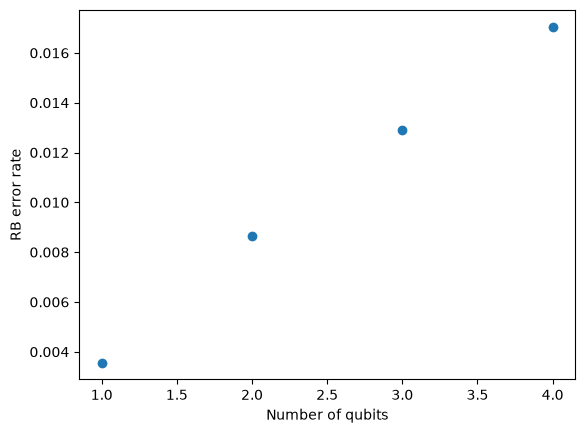

In [26]:
from matplotlib import pyplot as plt

plt.plot(widths, [r[w] for w in widths], 'o')
plt.xlabel('Number of qubits')
plt.ylabel('RB error rate')
plt.show()